In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


warnings.filterwarnings("ignore")

In [88]:
df=pd.read_csv('sleep_health_dataset.csv')

In [89]:
df = df.drop(["person_id","sleep_disorder_risk","felt_rested"], axis=1)

In [90]:
pd.set_option('display.max_columns', None)

In [91]:
df.head()

,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score
0,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4
1,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4
2,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5
3,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8
4,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   gender                       100000 non-null  object 
 2   occupation                   100000 non-null  object 
 3   bmi                          100000 non-null  float64
 4   country                      100000 non-null  object 
 5   sleep_duration_hrs           100000 non-null  float64
 6   sleep_quality_score          100000 non-null  float64
 7   rem_percentage               100000 non-null  float64
 8   deep_sleep_percentage        100000 non-null  float64
 9   sleep_latency_mins           100000 non-null  int64  
 10  wake_episodes_per_night      100000 non-null  int64  
 11  caffeine_mg_before_bed       100000 non-null  int64  
 12  alcohol_units_before_bed     100000 non-null  float64
 13  

In [93]:
obj_cols = df.select_dtypes(include='object')
for col in obj_cols.columns:
    print("\n", "="*50)
    print("COLUMN:", col)
    print("Unique count:", df[col].nunique())
    print(df[col].value_counts())


COLUMN: gender
Unique count: 3
gender
Female    50203
Male      47823
Other      1974
Name: count, dtype: int64

COLUMN: occupation
Unique count: 12
occupation
Student              14851
Software Engineer    12068
Nurse                10073
Manager               8101
Teacher               8047
Doctor                7868
Retired               7036
Sales                 7017
Freelancer            7016
Driver                6996
Homemaker             5923
Lawyer                5004
Name: count, dtype: int64

COLUMN: country
Unique count: 15
country
USA            20050
India          17840
Japan           8089
UK              8024
Brazil          7146
Germany         6026
Canada          4995
France          4982
Australia       4948
Italy           4018
South Korea     3971
Mexico          3888
Netherlands     3040
Spain           2011
Sweden           972
Name: count, dtype: int64

COLUMN: chronotype
Unique count: 3
chronotype
Neutral    45396
Evening    29643
Morning    24961
Name: co

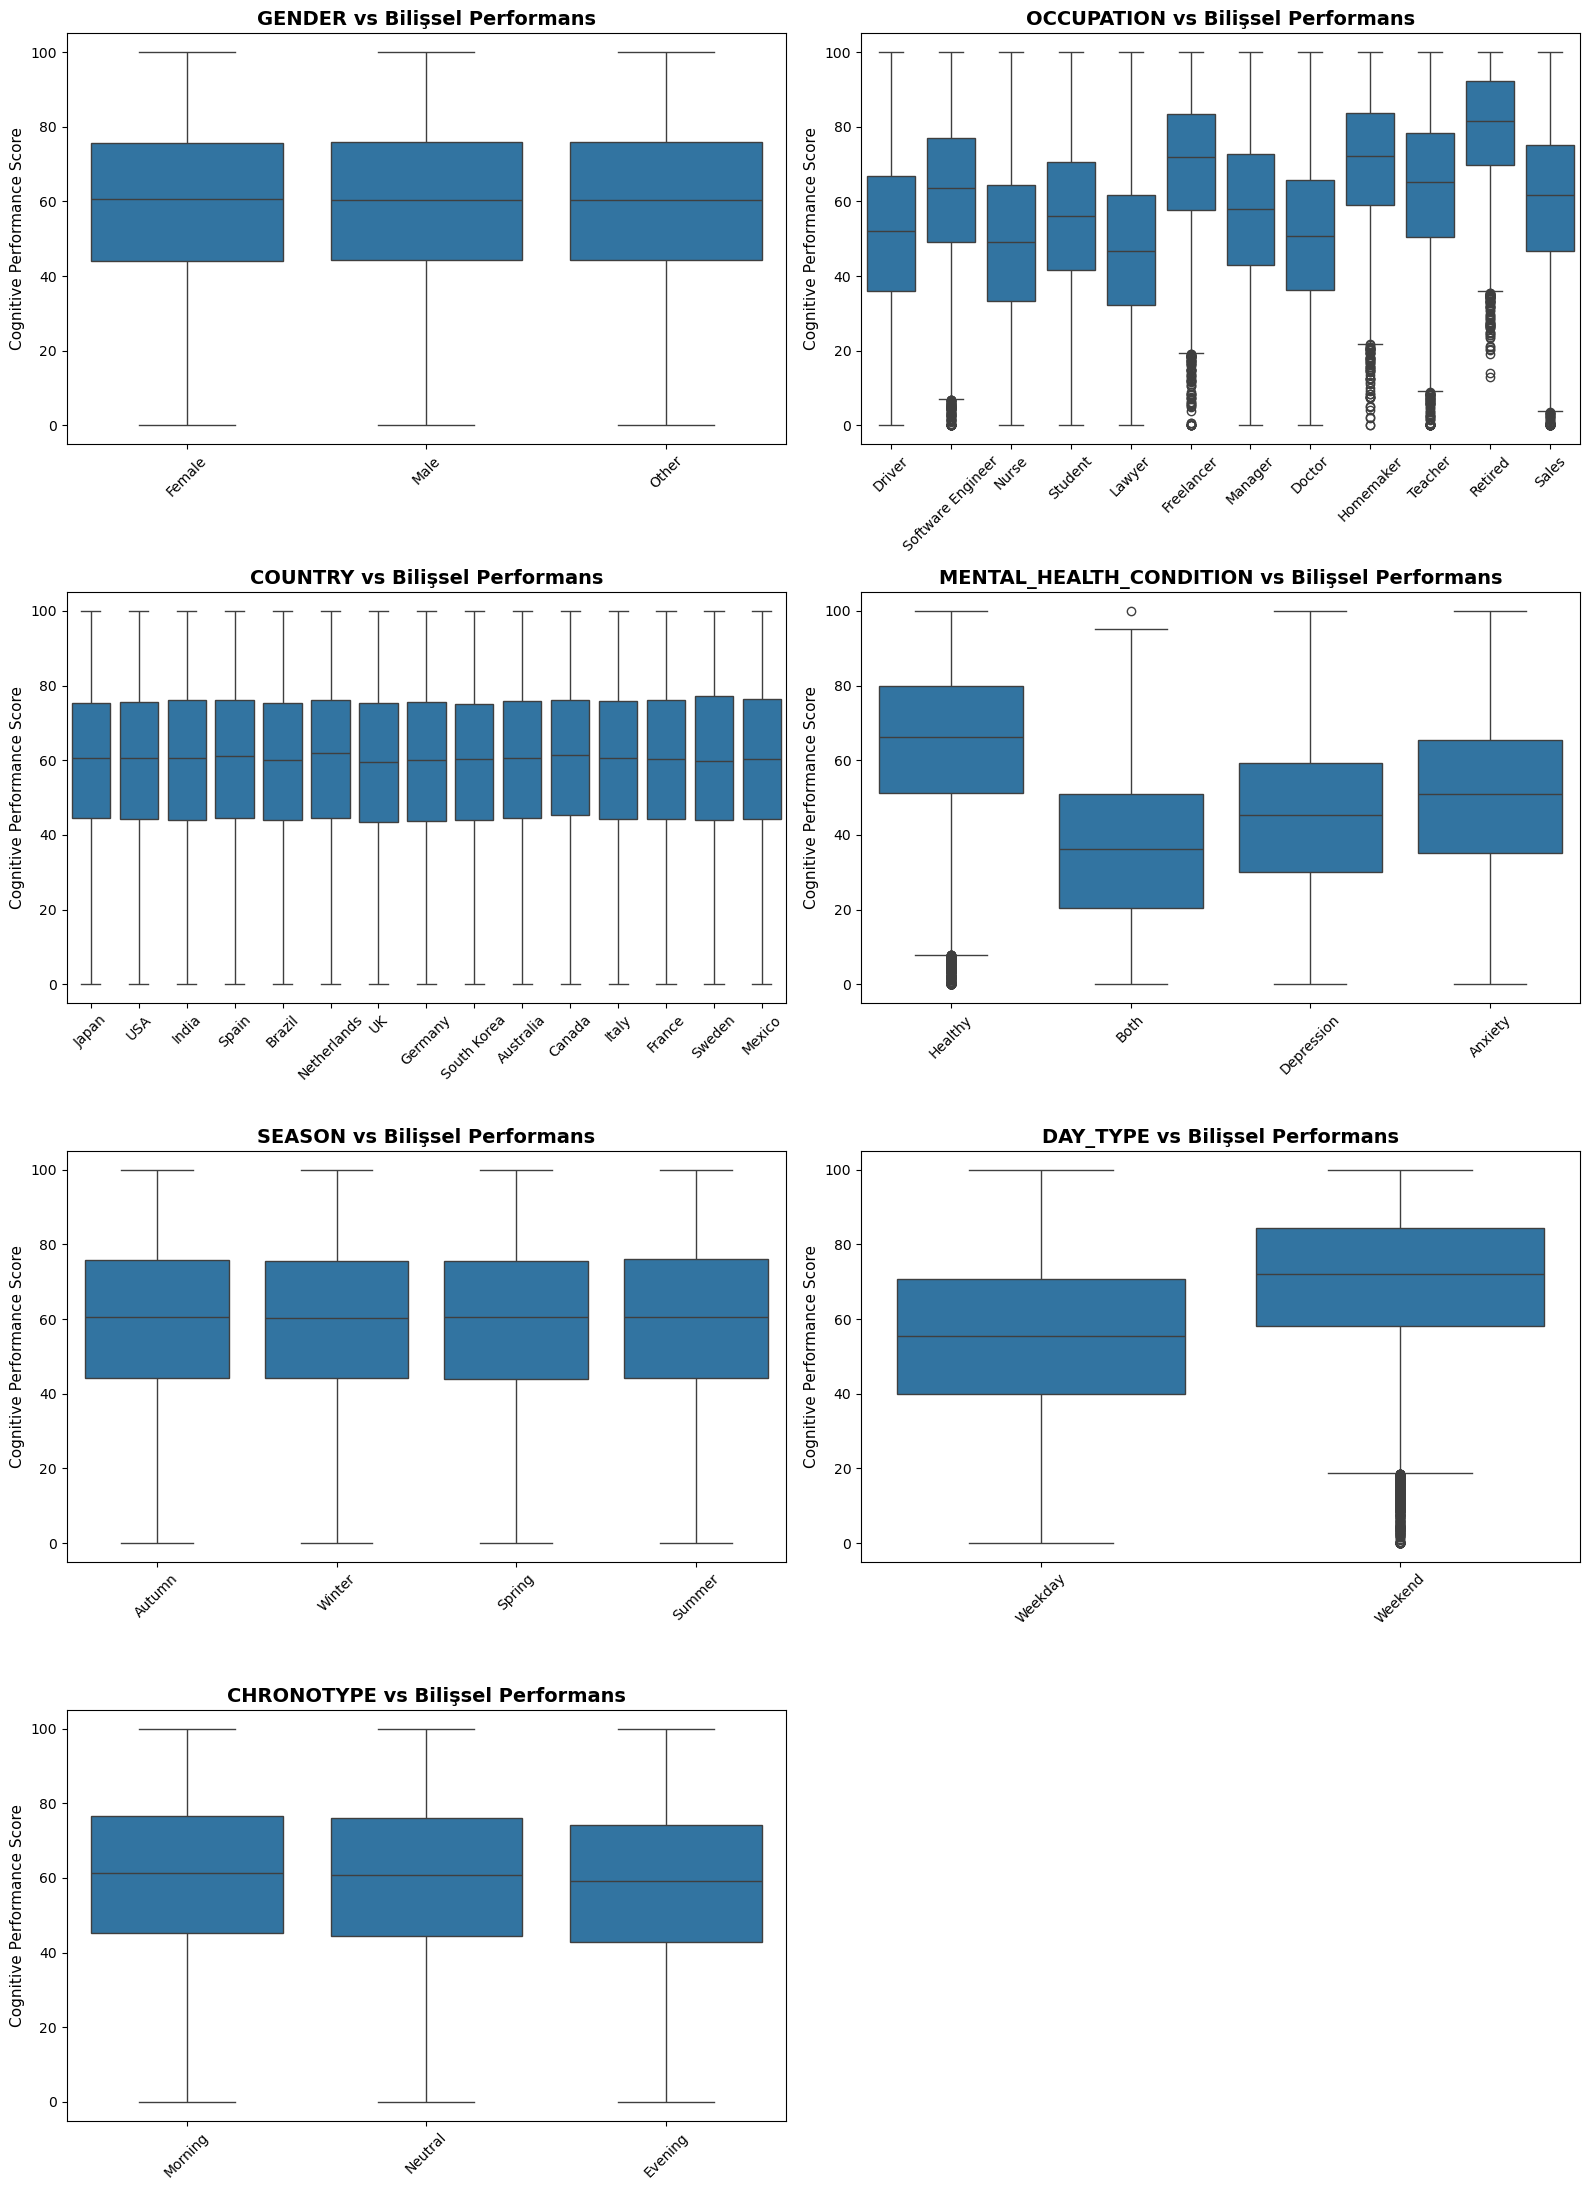

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = [
    "gender",
    "occupation",
    "country",
    "mental_health_condition",
    "season",
    "day_type",
    "chronotype",
]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(
        x=col, 
        y='cognitive_performance_score', 
        data=df, 
        ax=axes[i]
        
    )
    
    axes[i].set_title(f'{col.upper()} vs Bilişsel Performans', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cognitive Performance Score', fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)
fig.delaxes(axes[7])
plt.tight_layout()
plt.show()

In [95]:
df.groupby('occupation')['sleep_duration_hrs'].mean()

occupation
Doctor               5.929628
Driver               5.784877
Freelancer           7.335238
Homemaker            7.205664
Lawyer               5.744750
Manager              6.140412
Nurse                5.908215
Retired              8.034454
Sales                6.310150
Software Engineer    6.443267
Student              6.011794
Teacher              6.869544
Name: sleep_duration_hrs, dtype: float64

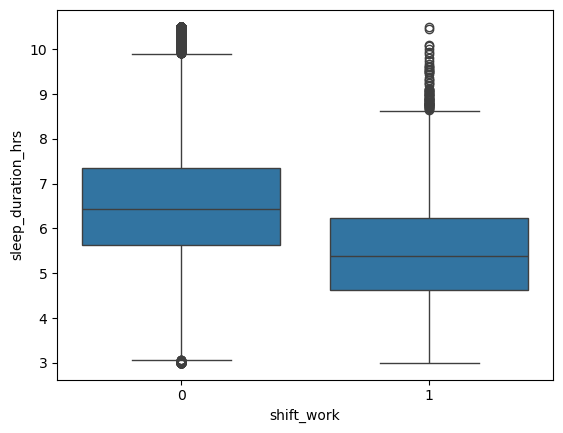

In [96]:
sns.boxplot(x=df['shift_work'],
            y=df['sleep_duration_hrs'])
plt.show()

In [97]:
cat_cols = ['gender', 'occupation', 'country', 'mental_health_condition', 'season', 'day_type','chronotype']
encoder = LabelEncoder()
df_encoded = df.copy()

for col in cat_cols + ['cognitive_performance_score']:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

mi_scores = mutual_info_classif(df_encoded[cat_cols], df_encoded['cognitive_performance_score'], random_state=42)
mi_df = pd.DataFrame({'Değişken': cat_cols, 'MI_Skoru': mi_scores})
mi_df = mi_df.sort_values(by='MI_Skoru', ascending=False).reset_index(drop=True)
mi_df

,Değişken,MI_Skoru
0,occupation,0.097582
1,mental_health_condition,0.095286
2,day_type,0.055716
3,season,0.007028
4,country,0.000963
5,gender,0.000000
6,chronotype,0.000000


In [98]:
df=df.drop(columns=['country', 'gender', 'season', 'chronotype'])

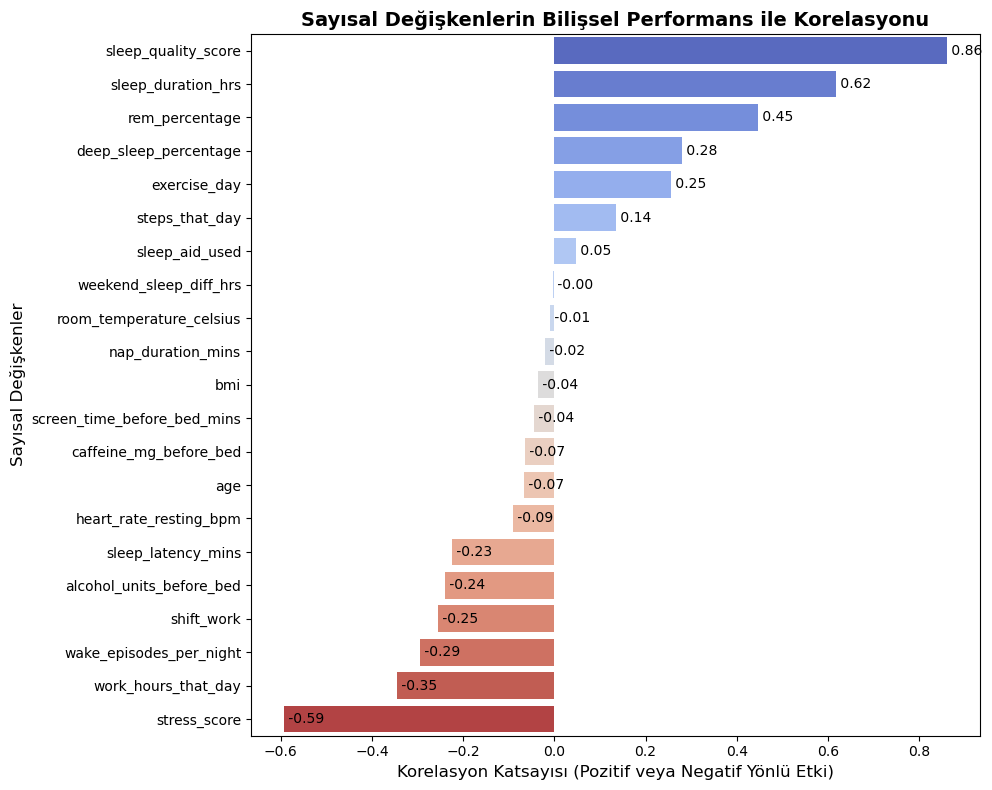

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['float64', 'int64', 'int32']).columns
corr_with_target = df[num_cols].corr()['cognitive_performance_score'].sort_values(ascending=False)
corr_with_target = corr_with_target.drop('cognitive_performance_score')

plt.figure(figsize=(10, 8))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
plt.title('Sayısal Değişkenlerin Bilişsel Performans ile Korelasyonu', fontsize=14, fontweight='bold')
plt.xlabel('Korelasyon Katsayısı (Pozitif veya Negatif Yönlü Etki)', fontsize=12)
plt.ylabel('Sayısal Değişkenler', fontsize=12)

for index, value in enumerate(corr_with_target.values):
    plt.text(value, index, f" {value:.2f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [100]:
low_corr_drops = [
    'weekend_sleep_diff_hrs', 
    'room_temperature_celsius', 
    'nap_duration_mins'
]
df = df.drop(columns=low_corr_drops)
df_info=df

In [101]:
df.head()

,age,occupation,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,stress_score,work_hours_that_day,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,day_type,cognitive_performance_score
0,29,Driver,25.7,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,4.4,10.7,Healthy,63,0,0,Weekday,73.4
1,55,Software Engineer,22.0,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,4.0,3.0,Healthy,52,1,0,Weekend,99.4
2,42,Nurse,25.0,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,7.8,3.6,Both,72,0,1,Weekend,2.5
3,37,Student,29.5,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,4.9,6.7,Healthy,71,0,0,Weekend,67.8
4,23,Lawyer,23.6,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,7.4,10.4,Healthy,71,0,0,Weekday,38.1


In [102]:
print(df.describe())

                 age            bmi  sleep_duration_hrs  sleep_quality_score  \
count  100000.000000  100000.000000       100000.000000        100000.000000   
mean       34.706870      26.289673            6.423986             4.871144   
std        11.036373       4.479578            1.274627             1.506517   
min        18.000000      16.000000            3.000000             1.000000   
25%        26.000000      23.200000            5.530000             3.800000   
50%        33.000000      26.300000            6.360000             4.900000   
75%        42.000000      29.300000            7.270000             6.000000   
max        69.000000      45.000000           10.500000            10.000000   

       rem_percentage  deep_sleep_percentage  sleep_latency_mins  \
count   100000.000000          100000.000000       100000.000000   
mean        20.243968              20.253375           19.836810   
std          3.411354               4.251096            7.584343   
min    

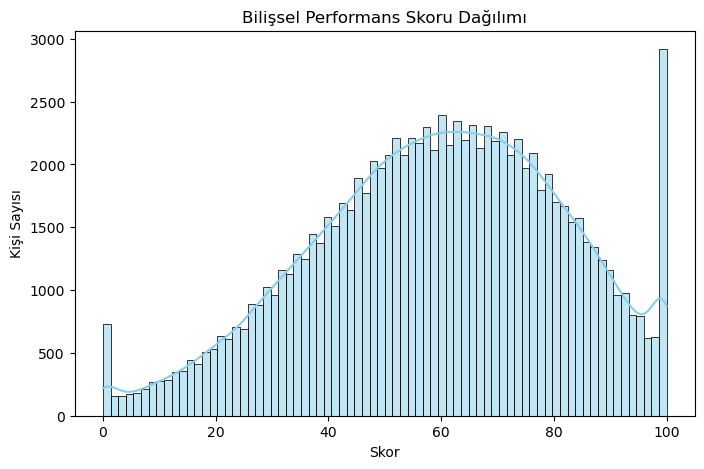

In [103]:
# Skorların genel dağılımını görmek için
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(df['cognitive_performance_score'], kde=True, color='skyblue')
plt.title('Bilişsel Performans Skoru Dağılımı')
plt.xlabel('Skor')
plt.ylabel('Kişi Sayısı')
plt.show()

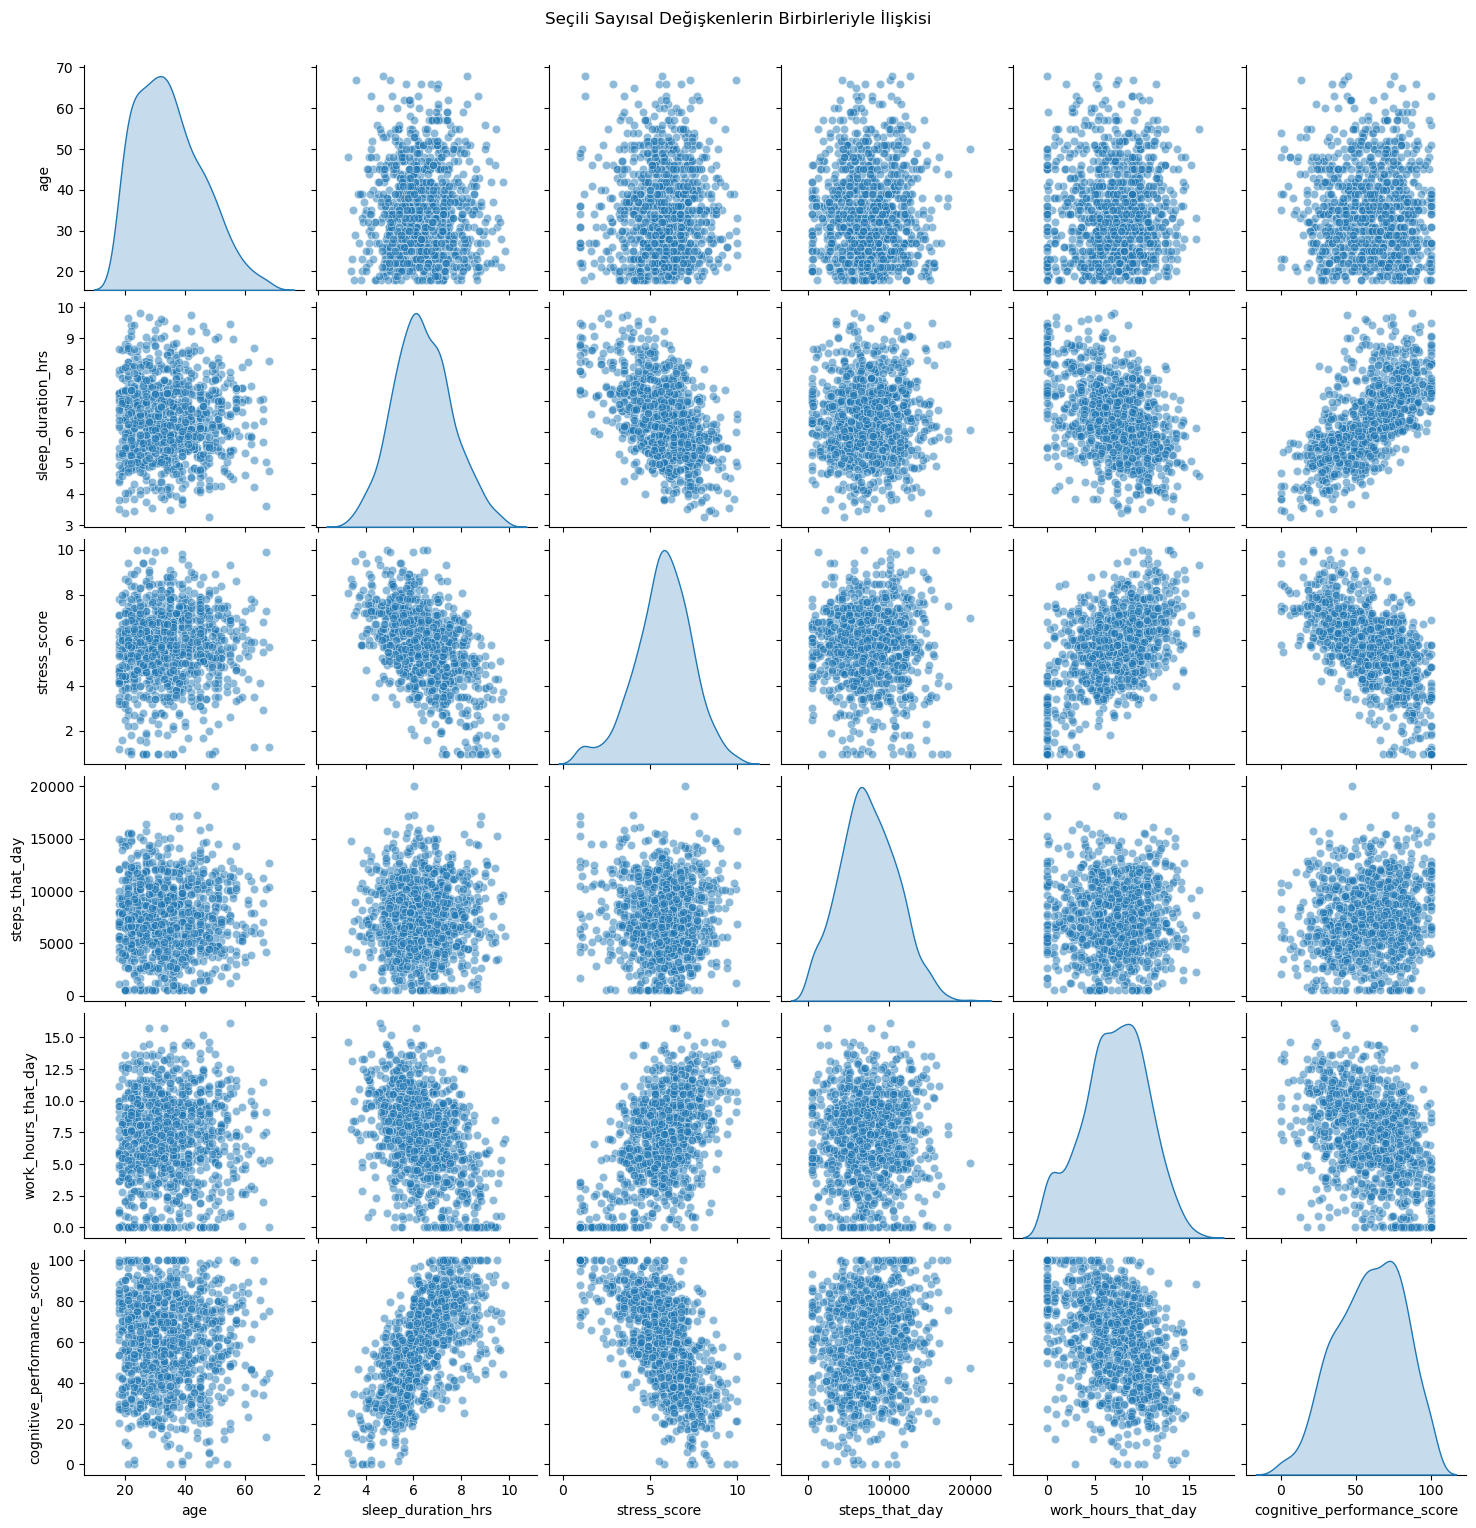

In [104]:
sayisal_sutunlar = df.select_dtypes(include=['int64', 'float64']).columns


analiz_listesi = ['age', 'sleep_duration_hrs', 'stress_score', 
                  'steps_that_day', 'work_hours_that_day', 'cognitive_performance_score']

sns.pairplot(df[analiz_listesi].sample(1000), diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Seçili Sayısal Değişkenlerin Birbirleriyle İlişkisi', y=1.02)
plt.show()

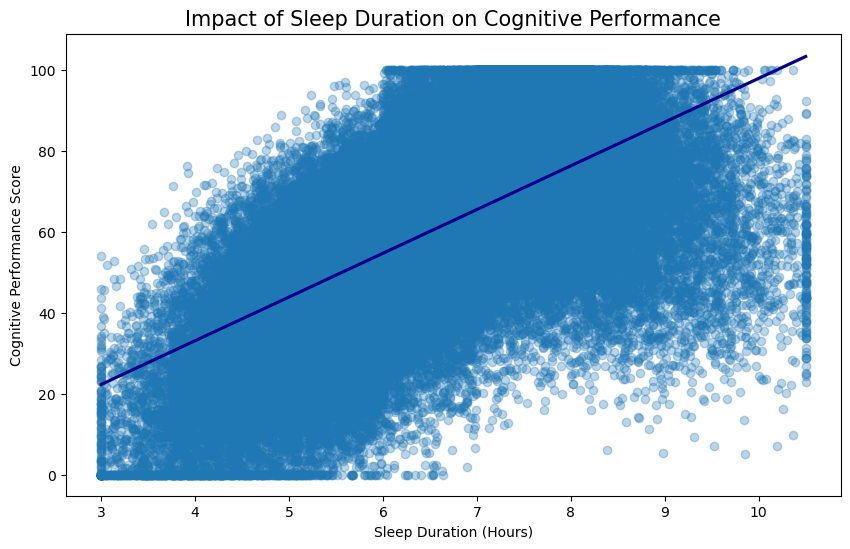

In [105]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='sleep_duration_hrs', y='cognitive_performance_score', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'darkblue'})
plt.title('Impact of Sleep Duration on Cognitive Performance', fontsize=15)
plt.xlabel('Sleep Duration (Hours)')
plt.ylabel('Cognitive Performance Score')
plt.show()

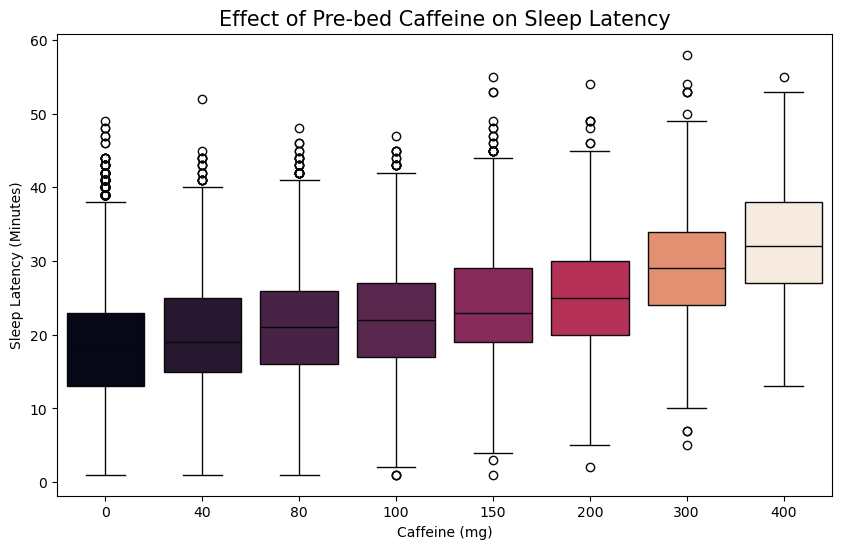

In [106]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='caffeine_mg_before_bed', y='sleep_latency_mins', hue='caffeine_mg_before_bed', palette='rocket', legend=False)
plt.title('Effect of Pre-bed Caffeine on Sleep Latency', fontsize=15)
plt.xlabel('Caffeine (mg)')
plt.ylabel('Sleep Latency (Minutes)')
plt.show()

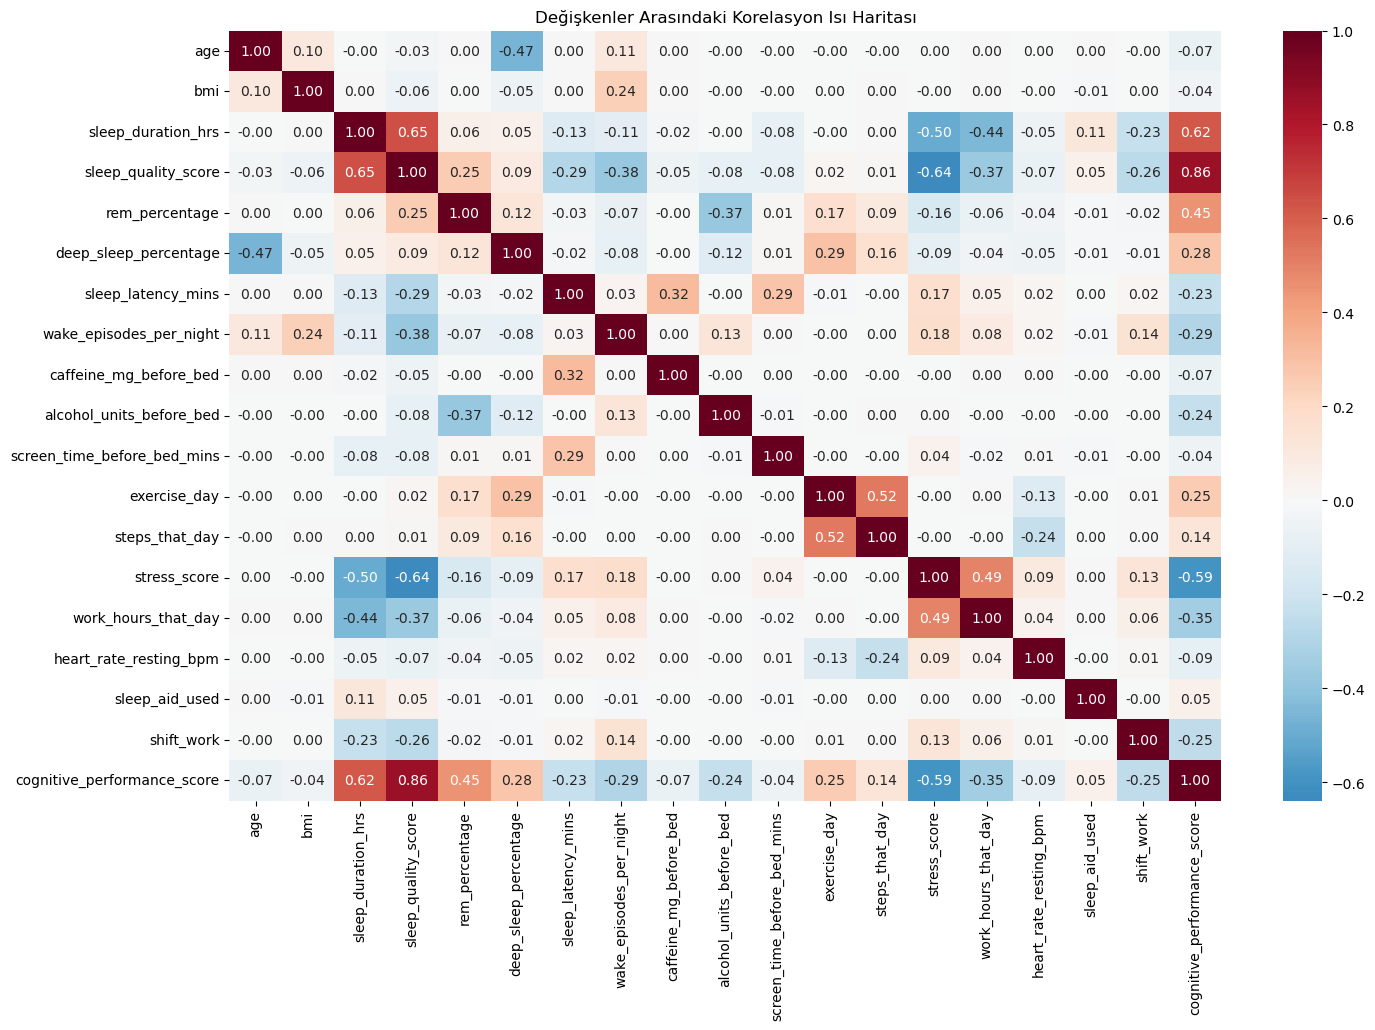

In [107]:

sayisal_veriler = df.select_dtypes(include=['number'])


corr = sayisal_veriler.corr()

plt.figure(figsize=(16, 10)) 

sns.heatmap(corr, 
            annot=True,     
            fmt=".2f",       
            cmap='RdBu_r',  
            center=0)        

plt.title('Değişkenler Arasındaki Korelasyon Isı Haritası')
plt.show()

In [108]:
mental_mapping = {
    'Healthy': 0,
    'Anxiety': 1,
    'Depression': 1, 
    'Both': 2
}
df['mental_health_condition'] = df['mental_health_condition'].map(mental_mapping)
df['day_type'] = df['day_type'].map({'Weekday': 0, 'Weekend': 1})
df = pd.get_dummies(df, columns=['occupation'], prefix='occ', dtype=int)

In [109]:
x = df.drop(columns=['cognitive_performance_score'])
y = df['cognitive_performance_score']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [110]:
sample_size = 10000
x_train_sample = x_train_scaled[:sample_size]
y_train_sample = y_train[:sample_size]

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5), 
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
}

results = []

for name, model in models.items():
    model.fit(x_train_sample, y_train_sample)
    y_pred = model.predict(x_test_scaled)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2_Skoru": r2
    })

In [111]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2_Skoru", ascending=False).reset_index(drop=True)
display(results_df)

,Model,RMSE,MAE,R2_Skoru
0,LightGBM,6.067480,4.846303,0.925086
1,XGBoost,6.493459,5.167928,0.914198
2,Random Forest,6.883658,5.475033,0.903576
3,Ridge (L2),7.148617,5.611190,0.896010
4,Linear Regression,7.148639,5.611220,0.896010
5,Lasso (L1),7.153715,5.620347,0.895862
6,ElasticNet,7.183713,5.641264,0.894987


In [112]:
param_dist_lgbm = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, -1],
    "num_leaves": [31, 50, 100],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [113]:
lgbm_base = LGBMRegressor(random_state=42, verbose=-1)

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist_lgbm,
    n_iter=25,
    scoring='r2',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [116]:
random_search_lgbm.fit(x_train_scaled, y_train)
best_lgbm_reg = random_search_lgbm.best_estimator_
for param, value in random_search_lgbm.best_params_.items():
    print(f" - {param}: {value}")
print("---------------------------")


y_pred = best_lgbm_reg.predict(x_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE (Kök Ortalama Kare Hatası): {rmse:}")
print(f"MAE (Ortalama Mutlak Hata):      {mae:}")
print(f"R2 Skoru:                        {r2:}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
 - subsample: 0.8
 - num_leaves: 100
 - n_estimators: 500
 - max_depth: 3
 - learning_rate: 0.1
 - colsample_bytree: 0.8
---------------------------
RMSE (Kök Ortalama Kare Hatası): 5.763682485139002
MAE (Ortalama Mutlak Hata):      4.611511928367069
R2 Skoru:                        0.9323999568609528


In [118]:
import joblib
joblib.dump(best_lgbm_reg, 'cognitive_model.joblib')
joblib.dump(scaler, 'cognitive_scaler.joblib')
model_columns = x_train.columns.tolist()
joblib.dump(model_columns, 'cognitive_columns.joblib')
mapping_dict = {
    'mental_mapping': {
        'Healthy': 0,
        'Anxiety': 1,
        'Depression': 1,
        'Both': 2
    },
    'day_type_mapping': {'Weekday': 0, 'Weekend': 1}
}
joblib.dump(mapping_dict, 'cognitive_mapping.joblib')

['cognitive_mapping.joblib']